In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# This copies your data from the slow Drive to the fast local /content/ folder
import shutil

print("🚚 Copying data to local storage (this takes a few minutes but saves hours later)...")
shutil.copytree("/content/drive/MyDrive/data", "/content/local_data", dirs_exist_ok=True)
print("✅ Done! Data is now on the local SSD.")

🚚 Copying data to local storage (this takes a few minutes but saves hours later)...
✅ Done! Data is now on the local SSD.


In [ ]:
import os
from pathlib import Path
import math
import random

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as T

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
data_dir = "/content/drive/MyDrive/data"   # change only if needed
local_data_dir = "/content/local_data"
print(os.listdir(data_dir))

['.DS_Store', 'train', 'validate', 'test']


Checking dataset

In [ ]:
from pathlib import Path

train_comp = Path(f"{data_dir}/train/compressed")
train_gt = Path(f"{data_dir}/train/ground_truth")

comp_files = sorted([p for p in train_comp.iterdir() if p.is_file()])
gt_files = sorted([p for p in train_gt.iterdir() if p.is_file()])

print("compressed count:", len(comp_files))
print("ground truth count:", len(gt_files))

print("sample compressed:", [p.name for p in comp_files[:10]])
print("sample ground truth:", [p.name for p in gt_files[:10]])

compressed count: 8000
ground truth count: 8000
sample compressed: ['1.jp2', '10.jp2', '100.jp2', '1000.jp2', '1001.jp2', '1002.jp2', '1003.jp2', '1004.jp2', '1005.jp2', '1006.jp2']
sample ground truth: ['1.png', '10.png', '100.png', '1000.png', '1001.png', '1002.png', '1003.png', '1004.png', '1005.png', '1006.png']


In [ ]:
comp_stems = {p.stem for p in comp_files}
gt_stems = {p.stem for p in gt_files}

only_in_comp = sorted(comp_stems - gt_stems)
only_in_gt = sorted(gt_stems - comp_stems)

print("Only in compressed:", len(only_in_comp))
print("Only in ground_truth:", len(only_in_gt))

print("Examples only in compressed:", only_in_comp[:20])
print("Examples only in ground_truth:", only_in_gt[:20])

Only in compressed: 0
Only in ground_truth: 0
Examples only in compressed: []
Examples only in ground_truth: []


DATASET CLASS

In [ ]:
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset
import torchvision.transforms as T
import torchvision.transforms.functional as TF  # Added the functional transforms

class PairedImageDataset(Dataset):
    def __init__(self, compressed_dir, ground_truth_dir, image_size=None, mode="RGB"):
        self.compressed_dir = Path(compressed_dir)
        self.ground_truth_dir = Path(ground_truth_dir)
        self.mode = mode
        self.image_size = image_size  # Saved as a class variable for later

        # 1. Gather all files
        comp_files = [p for p in self.compressed_dir.iterdir() if p.is_file()]
        gt_files = [p for p in self.ground_truth_dir.iterdir() if p.is_file()]

        # 2. Build the dictionaries mapping stems to full paths
        comp_map = {p.stem: p for p in comp_files}
        gt_map = {p.stem: p for p in gt_files}

        # 3. Find the exact matching overlapping pairs
        common_keys = sorted(set(comp_map.keys()) & set(gt_map.keys()))
        only_in_comp = sorted(set(comp_map.keys()) - set(gt_map.keys()))
        only_in_gt = sorted(set(gt_map.keys()) - set(comp_map.keys()))

        # 4. Print the debug/sanity check stats
        print(f"Matched pairs: {len(common_keys)}")
        print(f"Skipped (only in compressed): {len(only_in_comp)}")
        print(f"Skipped (only in ground_truth): {len(only_in_gt)}")

        if len(only_in_comp) > 0:
            print("Examples only in compressed:", only_in_comp[:10])
        if len(only_in_gt) > 0:
            print("Examples only in ground_truth:", only_in_gt[:10])

        # 5. Lock in the matched pairs
        self.pairs = [(comp_map[k], gt_map[k]) for k in common_keys]

        # 6. We only keep ToTensor here; cropping happens dynamically in __getitem__
        self.transform = T.Compose([T.ToTensor()])

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        comp_path, gt_path = self.pairs[idx]
        comp_img = Image.open(comp_path).convert(self.mode)
        gt_img = Image.open(gt_path).convert(self.mode)

        if self.image_size is not None:
            w, h = comp_img.size
            # If the image is too small, pad it to at least image_size
            pad_h = max(0, self.image_size - h)
            pad_w = max(0, self.image_size - w)

            if pad_h > 0 or pad_w > 0:
                # Add padding to the right and bottom using "reflect" to keep textures natural
                padding = (0, 0, pad_w, pad_h)
                comp_img = TF.pad(comp_img, padding, padding_mode='reflect')
                gt_img = TF.pad(gt_img, padding, padding_mode='reflect')

            # Now safe to get crop parameters
            i, j, h_crop, w_crop = T.RandomCrop.get_params(
                comp_img, output_size=(self.image_size, self.image_size)
            )
            comp_img = TF.crop(comp_img, i, j, h_crop, w_crop)
            gt_img = TF.crop(gt_img, i, j, h_crop, w_crop)

        return self.transform(comp_img), self.transform(gt_img), comp_path.name, gt_path.name

LOADING TRAIN/ VALIDATE / TEST SET WITH THIS CLASS

In [ ]:
IMAGE_SIZE = 256
MODE = "RGB"   # use "L" if grayscale

train_dataset = PairedImageDataset(
    compressed_dir=f"{local_data_dir}/train/compressed",
    ground_truth_dir=f"{local_data_dir}/train/ground_truth",
    image_size=IMAGE_SIZE,
    mode=MODE
)

val_dataset = PairedImageDataset(
    compressed_dir=f"{data_dir}/validate/compressed",
    ground_truth_dir=f"{data_dir}/validate/ground_truth",
    image_size=IMAGE_SIZE,
    mode=MODE
)

test_dataset = PairedImageDataset(
    compressed_dir=f"{data_dir}/test/compressed",
    ground_truth_dir=f"{data_dir}/test/ground_truth",
    image_size=IMAGE_SIZE,
    mode=MODE
)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

Matched pairs: 8000
Skipped (only in compressed): 0
Skipped (only in ground_truth): 0
Matched pairs: 1000
Skipped (only in compressed): 0
Skipped (only in ground_truth): 0
Matched pairs: 1000
Skipped (only in compressed): 0
Skipped (only in ground_truth): 0
Train size: 8000
Val size: 1000
Test size: 1000


DATALOADERS

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=4, pin_memory=True)

batch = next(iter(train_loader))
compressed_batch, gt_batch, comp_names, gt_names = batch

print(compressed_batch.shape)
print(gt_batch.shape)
print(comp_names[:3])
print(gt_names[:3])

torch.Size([64, 3, 256, 256])
torch.Size([64, 3, 256, 256])
('5375.jp2', '3790.jp2', '644.jp2')
('5375.png', '3790.png', '644.png')


DEFINE RESNET

In [ ]:
import torch
import torch.nn as nn

class UNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.PReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.PReLU()
        )

    def forward(self, x):
        return self.conv(x)

class UNetRestoration(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()

        # Encoder (Downsampling)
        self.enc1 = UNetBlock(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = UNetBlock(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = UNetBlock(128, 256)

        # Decoder (Upsampling)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = UNetBlock(256, 128) # 256 because of skip connection
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = UNetBlock(128, 64) # 128 because of skip connection

        self.final = nn.Conv2d(64, in_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))

        # Bottleneck
        b = self.bottleneck(self.pool2(e2))

        # Decoder with Skip Connections
        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1) # Concatenate along channel dim
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)

Training and validation functions

In [ ]:
import torch.optim as optim
from tqdm.notebook import tqdm

# 1. Setup
unet_model = UNetRestoration(in_channels=3).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(unet_model.parameters(), lr=2e-4) # Slightly higher LR for U-Net
EPOCHS = 50
best_val_loss = float('inf')

print(f"🚀 Starting U-Net Training on {device}...")

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()  # Sets the U-Net to training mode (activates BatchNorm)
    running_loss = 0.0

    pbar = tqdm(loader, desc="  Training", leave=False)

    for compressed, ground_truth, _, _ in pbar:
        compressed, ground_truth = compressed.to(device), ground_truth.to(device)

        optimizer.zero_grad()
        output = model(compressed)
        loss = criterion(output, ground_truth)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * compressed.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    return running_loss / len(loader.dataset)

@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.eval()  # Sets the U-Net to evaluation mode (freezes BatchNorm)
    running_loss = 0.0

    pbar = tqdm(loader, desc="  Validating", leave=False)

    for compressed, ground_truth, _, _ in pbar:
        compressed, ground_truth = compressed.to(device), ground_truth.to(device)
        output = model(compressed)
        loss = criterion(output, ground_truth)

        running_loss += loss.item() * compressed.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    return running_loss / len(loader.dataset)

for epoch in range(EPOCHS):
    # Use the same train/val functions we defined earlier!
    train_loss = train_one_epoch(unet_model, train_loader, criterion, optimizer, device)
    val_loss = validate_one_epoch(unet_model, val_loader, criterion, device)

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train: {train_loss:.6f} | Val: {val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(unet_model.state_dict(), "best_unet_weights.pth")
        print("  🌟 New Best U-Net Saved!")

🚀 Starting U-Net Training on cuda...


  Training:   0%|          | 0/125 [00:00<?, ?it/s]

  Validating:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch [01/50] | Train: 0.046653 | Val: 0.005033
  🌟 New Best U-Net Saved!


  Training:   0%|          | 0/125 [00:00<?, ?it/s]

...

  Validating:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch [49/50] | Train: 0.004117 | Val: 0.003757


  Training:   0%|          | 0/125 [00:00<?, ?it/s]

  Validating:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch [50/50] | Train: 0.004222 | Val: 0.003820


In [ ]:
# Make sure these are set in your earlier cells
IMAGE_SIZE = 256
BATCH_SIZE = 64
LEARNING_RATE = 2e-4
EPOCHS = 50

import torch.optim as optim

# 1. Initialize a fresh model and move to GPU
model = UNetRestoration(in_channels=3).to(device)

# 2. Setup Loss and Optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 3. Tracking variables
best_val_loss = float('inf')
history = {'train': [], 'val': []}

print(f"🚀 Starting Full Training: 50 Epochs on {device}...")

# 4. The Loop
for epoch in range(EPOCHS):
    # Train and Validate
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = validate_one_epoch(model, val_loader, criterion, device)

    # Store history for later plotting
    history['train'].append(train_loss)
    history['val'].append(val_loss)

    print(f"Epoch [{epoch+1:03d}/{EPOCHS}] | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    # Save only the BEST version
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_unet_weights.pth")
        print("  🌟 Checkpoint: New best model saved!")

print("🎉 Training Complete!")

In [ ]:
import torch
import numpy as np

def calculate_psnr(img1, img2):
    """Calculates PSNR between two tensors (0-1 range)"""
    mse = torch.mean((img1 - img2) ** 2)
    if mse == 0:
        return 100
    PIXEL_MAX = 1.0
    return 20 * torch.log10(PIXEL_MAX / torch.sqrt(mse))

# 1. Load the "Best" weights from your training
unet_model.load_state_dict(torch.load("best_unet_weights.pth"))
unet_model.eval()

total_psnr_improved = 0.0
total_psnr_compressed = 0.0
test_mse = 0.0

print("Evaluating on Test Set...")
with torch.no_grad():
    for compressed, gt, _, _ in test_loader:
        compressed, gt = compressed.to(device), gt.to(device)

        # Get model output
        output = unet_model(compressed)
        output = torch.clamp(output, 0, 1) # Ensure valid pixel range

        # Calculate MSE
        test_mse += torch.mean((output - gt) ** 2).item()

        # Calculate PSNR for BOTH (to see the improvement)
        total_psnr_improved += calculate_psnr(output, gt).item()
        total_psnr_compressed += calculate_psnr(compressed, gt).item()

avg_mse = test_mse / len(test_loader)
avg_psnr_out = total_psnr_improved / len(test_loader)
avg_psnr_comp = total_psnr_compressed / len(test_loader)

print(f"\n--- Final Results ---")
print(f"Average Test MSE: {avg_mse:.6f}")
print(f"Original Compressed PSNR: {avg_psnr_comp:.2f} dB")
print(f"AR-CNN Restored PSNR:    {avg_psnr_out:.2f} dB")
print(f"Net Improvement:         {avg_psnr_out - avg_psnr_comp:.2f} dB")

Evaluating on Test Set...

--- Final Results ---
Average Test MSE: 0.003749
Original Compressed PSNR: 24.99 dB
AR-CNN Restored PSNR:    25.28 dB
Net Improvement:         0.30 dB


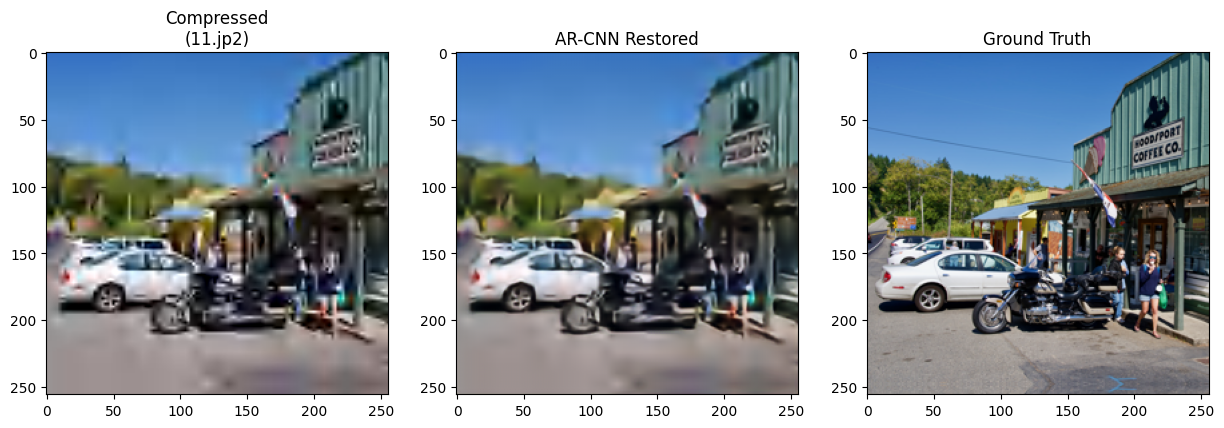

In [ ]:
def show_comparison(model, dataset, idx=0):
    model.eval()
    comp_img, gt_img, comp_name, _ = dataset[idx]

    # Prepare for model
    input_tensor = comp_img.unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(input_tensor).squeeze(0).cpu()
        output = torch.clamp(output, 0, 1)

    # Convert tensors to numpy for plotting
    comp_np = comp_img.permute(1, 2, 0).numpy()
    gt_np = gt_img.permute(1, 2, 0).numpy()
    out_np = output.permute(1, 2, 0).numpy()

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1); plt.imshow(comp_np); plt.title(f"Compressed\n({comp_name})")
    plt.subplot(1, 3, 2); plt.imshow(out_np); plt.title("AR-CNN Restored")
    plt.subplot(1, 3, 3); plt.imshow(gt_np); plt.title("Ground Truth")
    plt.show()

# Run it on a specific image index
show_comparison(unet_model, test_dataset, idx=13)